# Facility Access Gap Ranking

Rank zones by local demand and observation intensity to flag facility access gaps.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by common public-facility accessibility notebooks built with GeoPandas and Folium.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
zones = gpd.read_file(DATA / 'zones.geojson')
obs = pd.read_csv(DATA / 'observations.csv')
points = gpd.GeoDataFrame(obs, geometry=gpd.points_from_xy(obs.lon, obs.lat), crs='EPSG:4326')
print({'zones': len(zones), 'observations': len(points), 'crs': str(zones.crs)})
display(zones.head())


{'zones': 25, 'observations': 100, 'crs': 'EPSG:4326'}


,zone_id,district,score,population,green_ratio,geometry
0,Z0000,District 1,48.132423,4956,0.141492,"POLYGON ((118.725 31.9, 118.725 31.922, 118.7 ..."
1,Z0001,District 1,52.211968,11045,0.145592,"POLYGON ((118.76 31.9, 118.76 31.922, 118.735 ..."
2,Z0002,District 1,39.866390,10957,0.140527,"POLYGON ((118.795 31.9, 118.795 31.922, 118.77..."
3,Z0003,District 1,33.631042,8309,0.189656,"POLYGON ((118.83 31.9, 118.83 31.922, 118.805 ..."
4,Z0004,District 1,24.823360,5987,0.130861,"POLYGON ((118.865 31.9, 118.865 31.922, 118.84..."


In [2]:
joined = gpd.sjoin(points, zones[['zone_id', 'score', 'geometry']], predicate='within', how='left')
summary = joined.groupby('zone_id').agg(mean_value=('value', 'mean'), observations=('id', 'count')).reset_index()
zones2 = zones.merge(summary, on='zone_id', how='left').fillna({'mean_value': 0, 'observations': 0})
zones2['priority_index'] = (zones2['mean_value'] * 0.65 + zones2['score'] * 0.35).round(2)
display(zones2[['zone_id', 'score', 'mean_value', 'observations', 'priority_index']].sort_values('priority_index', ascending=False).head(8))


,zone_id,score,mean_value,observations,priority_index
1,Z0001,52.211968,80.200000,3.0,70.40
21,Z0401,60.056140,71.720000,1.0,67.64
7,Z0102,48.339531,77.500000,1.0,67.29
6,Z0101,55.787505,72.950000,2.0,66.94
2,Z0002,39.866390,79.552500,4.0,65.66
12,Z0202,50.407740,70.730000,2.0,63.62
10,Z0200,67.932272,59.306667,3.0,62.33
16,Z0301,64.733317,60.455000,2.0,61.95


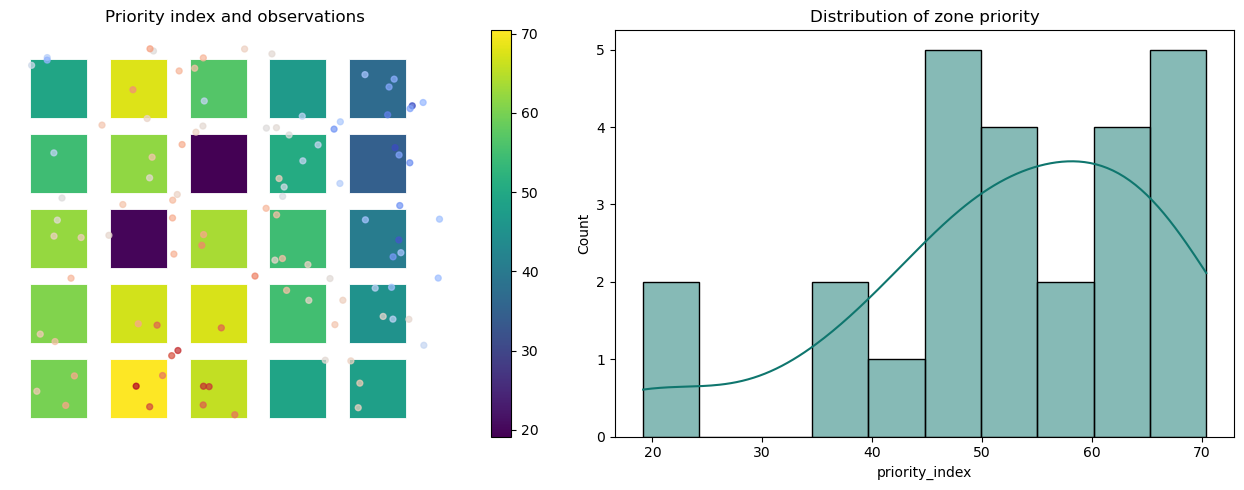

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
zones2.plot(column='priority_index', cmap='viridis', legend=True, ax=axes[0], edgecolor='white', linewidth=0.6)
points.plot(column='value', cmap='coolwarm', markersize=18, alpha=0.72, ax=axes[0])
axes[0].set_title('Priority index and observations')
axes[0].set_axis_off()
sns.histplot(zones2['priority_index'], bins=10, kde=True, ax=axes[1], color='#0f766e')
axes[1].set_title('Distribution of zone priority')
fig.tight_layout()
fig.savefig(OUT / 'priority_map.png', dpi=160)
plt.show()


In [4]:
center = [points.geometry.y.mean(), points.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=zones2.to_json(), data=zones2, columns=['zone_id', 'priority_index'], key_on='feature.properties.zone_id',
    fill_color='YlOrRd', fill_opacity=0.62, line_opacity=0.3, legend_name='Priority index'
).add_to(m)
for row in points.sample(min(35, len(points)), random_state=7).itertuples():
    folium.CircleMarker([row.lat, row.lon], radius=3, color='#1d4ed8', fill=True, fill_opacity=0.72, popup=f'{row.id}: {row.value}').add_to(m)
m.save(OUT / 'interactive_map.html')
display(m)


In [5]:
top = zones2.sort_values('priority_index', ascending=False).head(5)
print('Top intervention zones:')
for row in top.itertuples():
    print(f'- {row.zone_id}: priority={row.priority_index}, observations={int(row.observations)}')


Top intervention zones:
- Z0001: priority=70.4, observations=3
- Z0401: priority=67.64, observations=1
- Z0102: priority=67.29, observations=1
- Z0101: priority=66.94, observations=2
- Z0002: priority=65.66, observations=4
